# Notebook 3: Interpolation Method Comparison for $C^2$ Continuity

## Objective
Demonstrate the superiority of **Cubic Spline** and **RBF** interpolation for achieving $C^2$ continuity (continuous second derivatives). This property is essential for modeling natural fluid diffusion processes where concentration gradients must change smoothly.

**Methods Compared:**
1. **Polynomial**: Highlights Runge's Phenomenon (oscillatory artifacts).
2. **Piecewise Linear**: Shows jagged joints ($C^0$ only).
3. **Cubic Spline**: Achieves seamless $C^2$ transitions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries imported successfully.")

Libraries imported successfully.


## Data Preparation: 1D Profile Extraction
Extracting a slice of data along a constant latitude to visualize interpolation behavior in 1D.

In [2]:
df = pd.read_csv('../output/cleaned_water_pollution_data.csv')

# Extract a 1D profile
target_lat = df['Latitude'].median()
profile_df = df[(df['Latitude'] >= target_lat - 1.0) & (df['Latitude'] <= target_lat + 1.0)]
profile_df = profile_df.sort_values('Longitude').drop_duplicates('Longitude')

x_all = profile_df['Longitude'].values
y_all = profile_df['Heavy_Metals_Hg_ug_L'].values

# Subsample nodes for visualization
indices = np.linspace(0, len(x_all) - 1, 15, dtype=int)
x_nodes = x_all[indices]
y_nodes = y_all[indices]

x_fine = np.linspace(x_nodes.min(), x_nodes.max(), 500)
print(f"Nodes: {len(x_nodes)}, Evaluation Grid: {len(x_fine)}")

Nodes: 15, Evaluation Grid: 500


## Comparison: Polynomial vs. Linear vs. Cubic Spline

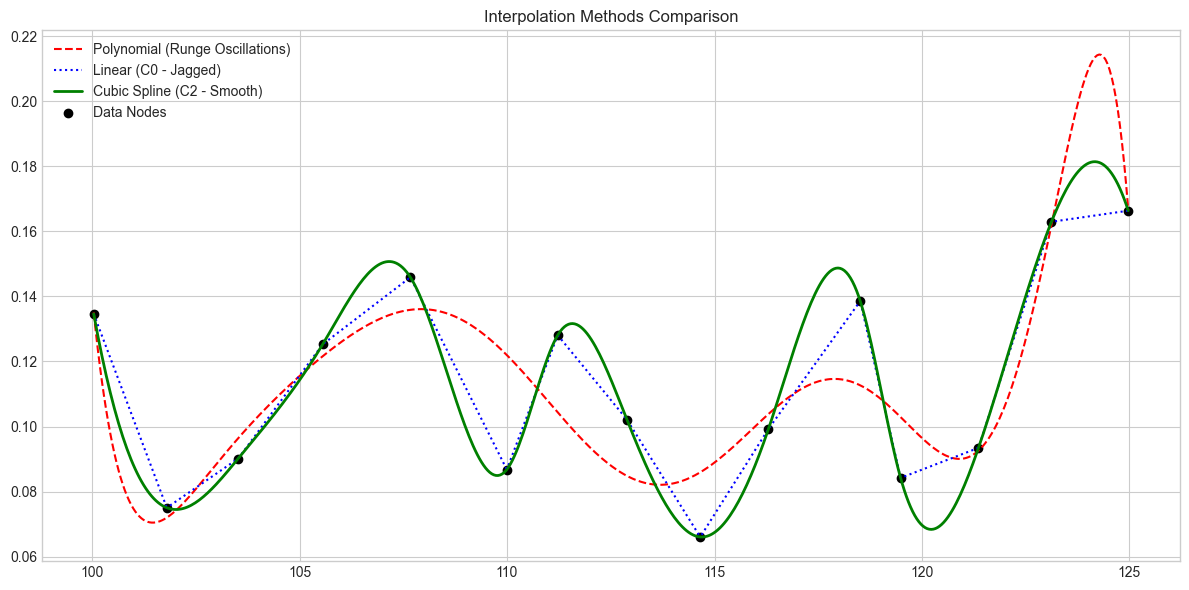

In [8]:
# 1. Polynomial (Degree 10 for demonstration)
poly_coeffs = np.polyfit(x_nodes, y_nodes, 10)
y_poly = np.polyval(poly_coeffs, x_fine)

# 2. Piecewise Linear (C0)
f_linear = interp1d(x_nodes, y_nodes, kind='linear')
y_linear = f_linear(x_fine)

# 3. Cubic Spline (C2)
f_cubic = CubicSpline(x_nodes, y_nodes)
y_cubic = f_cubic(x_fine)
y_cubic_2nd = f_cubic(x_fine, 2) # Second derivative

# Visualization
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(x_fine, y_poly, 'r--', label='Polynomial (Runge Oscillations)')
ax1.plot(x_fine, y_linear, 'b:', label='Linear (C0 - Jagged)')
ax1.plot(x_fine, y_cubic, 'g-', linewidth=2, label='Cubic Spline (C2 - Smooth)')
ax1.scatter(x_nodes, y_nodes, color='black', label='Data Nodes')
ax1.set_title("Interpolation Methods Comparison")
ax1.legend()


plt.tight_layout()
plt.show()

## Mathematical Foundation: Why $C^2$ Matters

The **Advection-Diffusion Equation** is defined as:

$$\frac{\partial C}{\partial t} = D\nabla^2 C - \mathbf{v} \cdot \nabla C + S$$

Where $\nabla^2 C$ is the Laplacian (second derivative). If our interpolation method only provides $C^0$ continuity (like Linear), the second derivative is undefined at the nodes, making the physics of the model break down at those points. **Cubic Splines** ensure that $\nabla^2 C$ is continuous, satisfying the requirements for natural diffusion.